# Цыпышев Т.А. ИУ5-51Б. Вариант 18. РК1

## Выполните задания (c помощью Python)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.distributions.empirical_distribution import ECDF

### Задача А
Возьмите результаты измерений из данных, полученных на семинаре 2 в эксперименте с моделью по характеристике «количество потерянных заявок на обслуживание» (столбец D на листе «эксперимент»):

1. Определите доверительную вероятность получения оценки среднего значения измеряемой величины с точностью $\varepsilon = 1$.
2. Найдите число измерений, необходимых для получения среднего значения с точностью $\varepsilon = 0.5$ и доверительной вероятностью $P=0.99$.

In [2]:
# Данные измерений
data_A = np.array([9, 8, 7, 15, 7, 7, 6, 7, 4, 7, 13, 6, 6, 8, 5, 6, 7, 12, 6, 6])
n_A = len(data_A)  # Количество измерений
mean_A = np.mean(data_A)  # Среднее значение
std_A = np.std(data_A, ddof=1)  # Стандартное отклонение (с поправкой на смещение)

In [3]:
# 1) Доверительная вероятность для ε = 1
epsilon = 1
# Находим t-значение для 95% доверительного интервала (двусторонний тест)
t_value = stats.t.ppf(1 - 0.05 / 2, df=n_A - 1)
# Рассчитываем доверительную вероятность (по формуле для t-распределения)
confidence_probability = stats.t.cdf(t_value, df=n_A - 1) - stats.t.cdf(-t_value, df=n_A - 1)

# 2) Число измерений для ε = 0.5 и P = 0.99
# Для P = 0.99 находим z-значение (для нормального распределения)
z_value = stats.norm.ppf(0.995)
# Рассчитываем необходимое количество измерений для точности ε = 0.5
required_n = (z_value * std_A / 0.5) ** 2

# Выводим результаты
print(f"Доверительная вероятность для ε = 1: {confidence_probability}")
print(f"Необходимое количество измерений для ε = 0.5 и P = 0.99: {np.ceil(required_n)}")


Доверительная вероятность для ε = 1: 0.9499999999999953
Необходимое количество измерений для ε = 0.5 и P = 0.99: 200.0


### Задача Б
В результате наблюдения было получено 100 значений признака, составляющих выборку из генеральной совокупности. Выполните задания:

1. Найдите выборочное среднее, выборочную дисперсию, среднеквадратическое отклонение, размах данных, максимум и минимум.
2. Оцените математическое ожидание генеральной совокупности с помощью доверительного интервала с надёжностями $0.95$, $0.99$, $0.999$.
3. Постройте гистограмму частот.
4. Постройте график плотности нормального распределения с параметрами выборки.
5. Постройте диаграмму размаха данных (в Python – график `boxplot`; в Excel – биржевая диаграмма, блочная диаграмма с ограничителями — показывает распределение данных по квартилям с выбросами).
6. Примените критерий Пирсона $\chi^2$ с уровнем значимости $0.05$ для проверки гипотезы о нормальном распределении генеральной совокупности. Сделайте вывод о принятии основной гипотезы.

#### Данные выборки Б:

|    |    |    |    |    |    |    |    |    |    |
|----|----|----|----|----|----|----|----|----|----|
| 108 | 113 | 105 | 110 | 117 | 116 | 111 | 104 | 115 | 110 |
| 98  | 104 | 110 | 117 | 113 | 114 | 107 | 113 | 107 | 101 |
| 112 | 108 | 116 | 110 | 111 | 103 | 111 | 115 | 110 | 108 |
| 95  | 103 | 107 | 107 | 107 | 107 | 107 | 100 | 104 | 103 |
| 92  | 105 | 106 | 106 | 103 | 92  | 104 | 106 | 105 | 100 |
| 102 | 114 | 102 | 122 | 122 | 99  | 102 | 114 | 102 | 99  |
| 101 | 112 | 112 | 115 | 101 | 96  | 121 | 101 | 118 | 101 |
| 97  | 100 | 109 | 97  | 91  | 100 | 109 | 100 | 97  | 97  |
| 106 | 113 | 120 | 93  | 106 | 119 | 109 | 106 | 98  | 93  |
| 105 | 108 | 118 | 122 | 105 | 118 | 108 | 105 | 108 | 105 |

In [4]:
# Данные измерений
data_B = np.array([108, 113, 105, 110, 117, 116, 111, 104, 115, 110,
                   98, 104, 110, 117, 113, 114, 107, 113, 107, 101,
                   112, 108, 116, 110, 111, 103, 111, 115, 110, 108,
                   95, 103, 107, 107, 107, 107, 107, 100, 104, 103,
                   92, 105, 106, 106, 103, 92, 104, 106, 105, 100,
                   102, 114, 102, 122, 122, 99, 102, 114, 102, 99,
                   101, 112, 112, 115, 101, 96, 121, 101, 118, 101,
                   97, 100, 109, 97, 91, 100, 109, 100, 97, 97,
                   106, 113, 120, 93, 106, 119, 109, 106, 98, 93,
                   105, 108, 118, 122, 105, 118, 108, 105, 108, 105])

In [5]:
# Основные статистические характеристики
mean_B = np.mean(data_B)  # Среднее значение
var_B = np.var(data_B, ddof=1)  # Дисперсия (с поправкой на смещение)
std_B = np.std(data_B, ddof=1)  # Стандартное отклонение
min_B, max_B = np.min(data_B), np.max(data_B)  # Минимум и максимум
range_B = max_B - min_B  # Размах

print(f"Выборочное среднее: {mean_B:.2f}")
print(f"Выборочная дисперсия: {var_B:.2f}")
print(f"Среднеквадратическое отклонение: {std_B:.2f}")
print(f"Размах данных: {range_B}")
print(f"Минимум: {min_B}, Максимум: {max_B}")

Выборочное среднее: 106.74
Выборочная дисперсия: 53.37
Среднеквадратическое отклонение: 7.31
Размах данных: 31
Минимум: 91, Максимум: 122


In [6]:
# Вычисление доверительных интервалов для различных уровней значимости
alpha_levels = [0.95, 0.99, 0.999]
conf_intervals = {alpha: stats.t.interval(alpha, df=len(data_B)-1, loc=mean_B, scale=std_B/np.sqrt(len(data_B))) for alpha in alpha_levels}

# Вывод доверительных интервалов
for alpha, interval in conf_intervals.items():
    print(f"Доверительный интервал для α = {alpha}: {interval}")

Доверительный интервал для α = 0.95: (np.float64(105.29048829026071), np.float64(108.18951170973928))
Доверительный интервал для α = 0.99: (np.float64(104.82135624385373), np.float64(108.65864375614626))
Доверительный интервал для α = 0.999: (np.float64(104.26241772043065), np.float64(109.21758227956936))


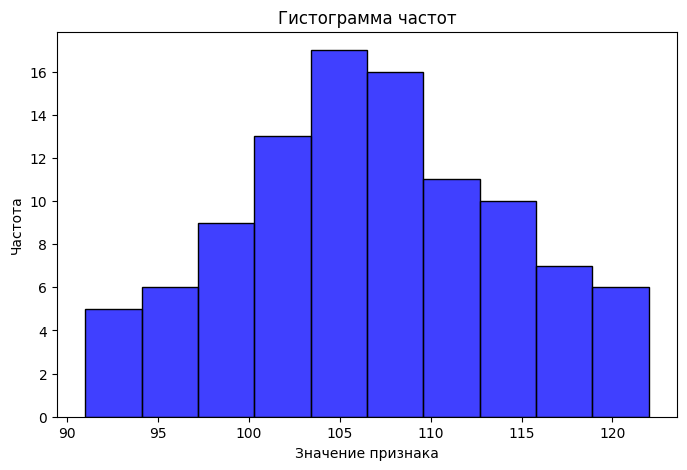

In [7]:
# Построение гистограммы
plt.figure(figsize=(8, 5))
sns.histplot(data_B, bins=10, kde=False, color='blue', edgecolor='black')
plt.title('Гистограмма частот')
plt.xlabel('Значение признака')
plt.ylabel('Частота')
plt.show()

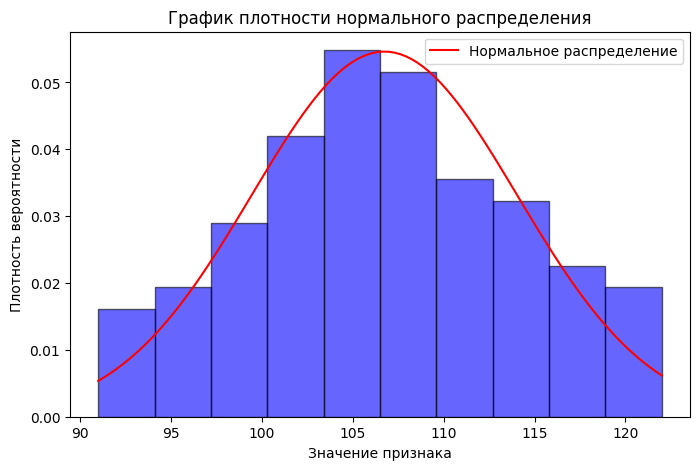

In [8]:
# График плотности нормального распределения
x = np.linspace(min_B, max_B, 100)
y = stats.norm.pdf(x, mean_B, std_B)

plt.figure(figsize=(8, 5))
plt.plot(x, y, color='red', label='Нормальное распределение')
plt.hist(data_B, bins=10, density=True, alpha=0.6, color='blue', edgecolor='black')
plt.title('График плотности нормального распределения')
plt.xlabel('Значение признака')
plt.ylabel('Плотность вероятности')
plt.legend()
plt.show()

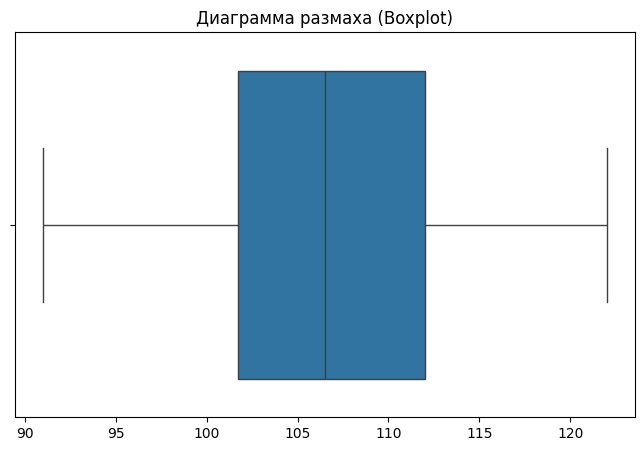

In [9]:
# Диаграмма размаха (Boxplot)
plt.figure(figsize=(8, 5))
sns.boxplot(x=data_B)
plt.title('Диаграмма размаха (Boxplot)')
plt.show()

In [10]:
# Критерий Пирсона χ² для проверки нормальности распределения
observed_freq, bins = np.histogram(data_B, bins='auto')

# Ожидаемые частоты, основанные на нормальном распределении
expected_freq = len(data_B) * np.diff(stats.norm.cdf(bins, loc=mean_B, scale=std_B))
# Нормализуем ожидаемые частоты, чтобы сумма совпала с наблюдаемыми
expected_freq *= np.sum(observed_freq) / np.sum(expected_freq)

# Проверяем, что суммы совпадают
assert np.isclose(np.sum(observed_freq), np.sum(expected_freq), rtol=1e-8), "Суммы не совпадают!"

# Вычисление статистики χ² и p-значения
chi2_stat, p_value = stats.chisquare(f_obs=observed_freq, f_exp=expected_freq)

print(f"χ²-статистика: {chi2_stat:.4f}")
print(f"p-значение: {p_value:.4f}")

χ²-статистика: 1.8724
p-значение: 0.9666


### Задача В
1. Сравните распределения выборок Б и В с помощью критерия Колмогорова-Смирнова. Сделайте вывод о принятии основной гипотезы.
2. Постройте график распределения (CDF) этой выборки.
3. Постройте график эмпирической функции плотности (полигон частот) этой выборки.

#### Данные выборки В:

|    |    |    |    |    |    |    |    |    |    |
|----|----|----|----|----|----|----|----|----|----|
| 109.36 | 121.10 | 115.78 | 98.19  | 98.38  | 108.38 | 98.14  | 93.99  | 100.54 | 114.69 |
| 122.48 | 107.18 | 97.99  | 94.26  | 107.88 | 106.89 | 96.68  | 94.56  | 100.57 | 118.59 |
| 103.06 | 116.36 | 94.74  | 96.65  | 115.84 | 105.43 | 95.23  | 95.12  | 103.22 | 111.36 |
| 105.72 | 110.96 | 107.38 | 67.06  | 114.35 | 103.97 | 93.77  | 95.68  | 105.86 | 101.06 |
| 107.18 | 97.99  | 115.84 | 105.43 | 95.12  | 103.22 | 114.15 | 112.73 | 113.22 | 96.80 |
| 116.36 | 94.74  | 114.35 | 103.97 | 95.68  | 105.86 | 107.65 | 107.91 | 109.63 | 108.74 |
| 110.96 | 107.38 | 112.86 | 102.52 | 96.24  | 104.71 | 105.34 | 110.25 | 118.27 | 104.02 |

In [11]:
data_C = np.array([109.36, 121.10, 115.78, 98.19, 98.38, 108.38, 98.14, 93.99, 100.54, 114.69,
                   122.48, 107.18, 97.99, 94.26, 107.88, 106.89, 96.68, 94.56, 100.57, 118.59,
                   103.06, 116.36, 94.74, 96.65, 115.84, 105.43, 95.23, 95.12, 103.22, 111.36,
                   105.72, 110.96, 107.38, 67.06, 114.35, 103.97, 93.77, 95.68, 105.86, 101.06,
                   107.18, 97.99, 115.84, 105.43, 95.12, 103.22, 114.15, 112.73, 113.22, 96.80,
                   116.36, 94.74, 114.35, 103.97, 95.68, 105.86, 107.65, 107.91, 109.63, 108.74,
                   110.96, 107.38, 112.86, 102.52, 96.24, 104.71, 105.34, 110.25, 118.27, 104.02])

In [12]:
# 1. Критерий Колмогорова-Смирнова (KS)
ks_stat, ks_p_value = stats.ks_2samp(data_B, data_C)

# Печать результатов
print("Результаты теста Колмогорова-Смирнова:")
print(f"Статистика: {ks_stat:.4f}, p-значение: {ks_p_value:.4f}")

# Проверка гипотез на основе уровня значимости alpha
alpha = 0.05  # уровень значимости

# Тест Колмогорова-Смирнова
if ks_p_value < alpha:
    print("\nРезультаты теста Колмогорова-Смирнова: Отвергаем нулевую гипотезу (распределения различаются).")
else:
    print("\nРезультаты теста Колмогорова-Смирнова: Не отвергаем нулевую гипотезу (распределения одинаковы).")


Результаты теста Колмогорова-Смирнова:
Статистика: 0.1700, p-значение: 0.1632

Результаты теста Колмогорова-Смирнова: Не отвергаем нулевую гипотезу (распределения одинаковы).


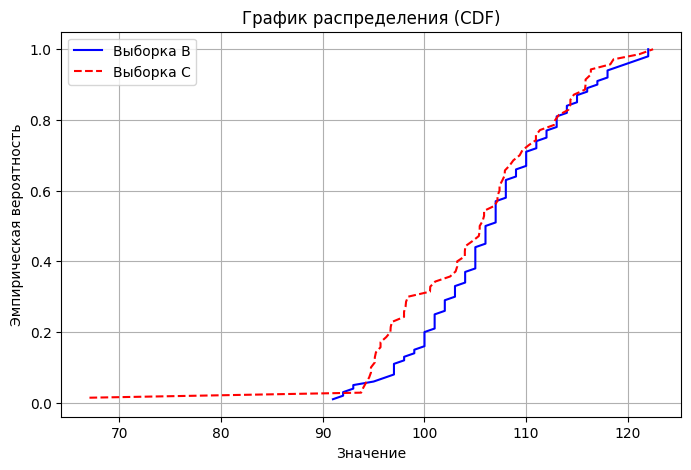

In [13]:
# Построение графика эмпирических функций распределения (CDF)
ecdf_B = ECDF(data_B)
ecdf_C = ECDF(data_C)

plt.figure(figsize=(8, 5))
plt.plot(ecdf_B.x, ecdf_B.y, label="Выборка B", color='blue')
plt.plot(ecdf_C.x, ecdf_C.y, label="Выборка C", linestyle='dashed', color='red')
plt.title("График распределения (CDF)")
plt.xlabel("Значение")
plt.ylabel("Эмпирическая вероятность")
plt.legend()
plt.grid(True)
plt.show()

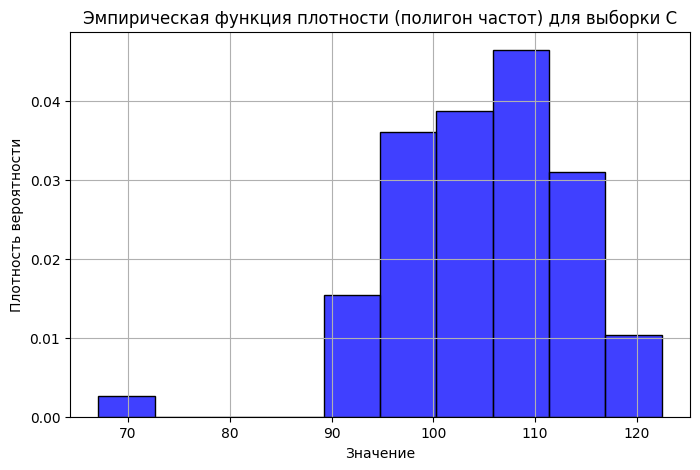

In [14]:
# 2. Полигон частот для выборки C
plt.figure(figsize=(8, 5))
sns.histplot(data_C, bins=10, kde=False, color='blue', edgecolor='black', stat="density")
plt.title('Эмпирическая функция плотности (полигон частот) для выборки C')
plt.xlabel("Значение")
plt.ylabel("Плотность вероятности")
plt.grid(True)
plt.show()

In [15]:
# 3. (ЕСЛИ НУЖНО ДОПОЛЕИТЕЛЬНО!!!) провести хи-квадрат тест
# (Убедитесь, что этот шаг требуется по заданию. Если нет, его можно удалить.)
observed_freq, bin_edges = np.histogram(data_C, bins=10)
# Ожидаемые частоты из выборки B, привязанные к тем же бинам
expected_freq = np.histogram(data_B, bins=bin_edges)[0]

# Исключаем бины с нулевыми ожидаемыми частотами
non_zero_bins = expected_freq > 0
observed_freq = observed_freq[non_zero_bins]
expected_freq = expected_freq[non_zero_bins]

# Нормализация частот, чтобы суммы совпали
observed_freq = observed_freq / observed_freq.sum()
expected_freq = expected_freq / expected_freq.sum()

# Проводим хи-квадрат тест
chi2_stat, chi2_p_value = stats.chisquare(observed_freq, expected_freq)

# Выводим результаты
print("\nРезультаты хи-квадрат теста:")
print(f"Статистика: {chi2_stat:.4f}, p-значение: {chi2_p_value:.4f}")

# Тест хи-квадрат
if chi2_p_value < alpha:
    print("\nРезультаты хи-квадрат теста: Отвергаем нулевую гипотезу (распределения различаются).")
else:
    print("\nРезультаты хи-квадрат теста: Не отвергаем нулевую гипотезу (распределения одинаковы).")


Результаты хи-квадрат теста:
Статистика: 0.0816, p-значение: 0.9999

Результаты хи-квадрат теста: Не отвергаем нулевую гипотезу (распределения одинаковы).
